In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="darkgrid", palette="viridis")

In [58]:
path= 'credit_risk_dataset.csv'
df= pd.read_csv(path)

In [59]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


### EDA

In [61]:
#Questions to answer:
# what are we studying
# how was our data collected
# where, when
# what is the target variable
# based on prior knowledge what features we think influence Y the most, lets explore them.
# outliers / nan values (what do they represent, can they be fixed / ignored)

In [62]:
#1 we are studying unsecured credit loans and their default rate
# to make better decision about credit loan grants in the future.
#2 it appears our data is collected through omitting the person's name & id
# and simply stack the loans that were granted on top of each other, (we'll try to fix that by adding id later)
#3 where and when is not disclosed here
#4 target variable is the loan_status (0 - 1)
#5 All are interesting .

In [72]:
# questions about features influence on y:
# are young people / low income people likely to default ?
# > is that person's a freshman at a company (low p.e.l) and is expected to generate higher incomes
# does the home_ownership status affect the loan_status
# does loan_grade have anything to do with defaults, and are whats the mean age for those with low grade
# does loan_int_rate affect the loan_status or broadly the (l.p.e)
# does the person's default_history affect the loan_status
# does the person's credit_history affect the loan, are youngsters related ?
# loan_amount and its relation with intent and the age/income.
# do we need an indicator 

In [64]:
#checking for duplicated lines
print('Duplicated lines:', len(df[df.duplicated()]))
#fixing that:
df= df[~df.duplicated()]
df.reset_index(drop= True, inplace= True)

Duplicated lines: 165


In [65]:
df[df.duplicated(subset= ['person_age','person_income','person_home_ownership',
                       'person_emp_length','cb_person_default_on_file',
                       'cb_person_cred_hist_length'], keep= False)].shape
# 5835 duplicated lines, means more than one person took multiple loans at once.

(5835, 12)

In [66]:
cols= ['person_age','person_income','person_home_ownership',
                       'person_emp_length','cb_person_default_on_file',
                       'cb_person_cred_hist_length']
df['id']= df.groupby(cols, dropna= False).ngroup()
df['count'] = df.groupby('id', dropna= False)['id'].transform('count')

In [67]:
len(df['id'].unique()) #appears there are 29031 unique people recorded taking loans

29031

In [88]:
colors= ['#4d5359','#fa6d76', '#fafafb', '#fca8ad', '#a3a9af', '#fecacb', '#fb888f', '#fa5560']

In [69]:
# imbalanced data-set 'we're interested in those that defaulted generally
df['loan_status'].value_counts(normalize= True) \
    .mul(100).round(1) \
    .astype('str').add(' %')

loan_status
0    78.1 %
1    21.9 %
Name: proportion, dtype: object

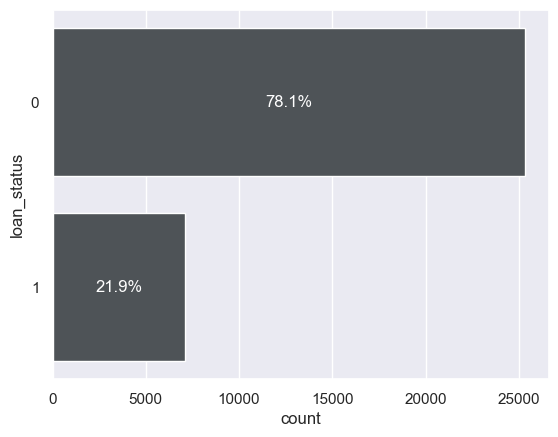

In [ ]:
plt.figure()
sns.countplot(data= df, y= 'loan_status', color= colors[0])
plt.bar_label(plt.gca().containers[0], 
             labels=df['loan_status'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%',
             label_type='center', color='white')
plt.show()

In [74]:
# questions about features influence on y:
# are young people / low income people likely to default ?
# > is that person's a freshman at a company (low p.e.l) and is expected to generate higher incomes
# does the home_ownership status affect the loan_status
# does loan_grade have anything to do with defaults, and are whats the mean age for those with low grade
# does loan_int_rate affect the loan_status or broadly the (l.p.e)
# does the person's default_history affect the loan_status
# does the person's credit_history affect the loan, are youngsters related ?
# loan_amount and its relation with intent and the age/income.
# do we need an indicator 

In [79]:
df.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length', 'id',
       'count'],
      dtype='object')

<Figure size 640x480 with 0 Axes>

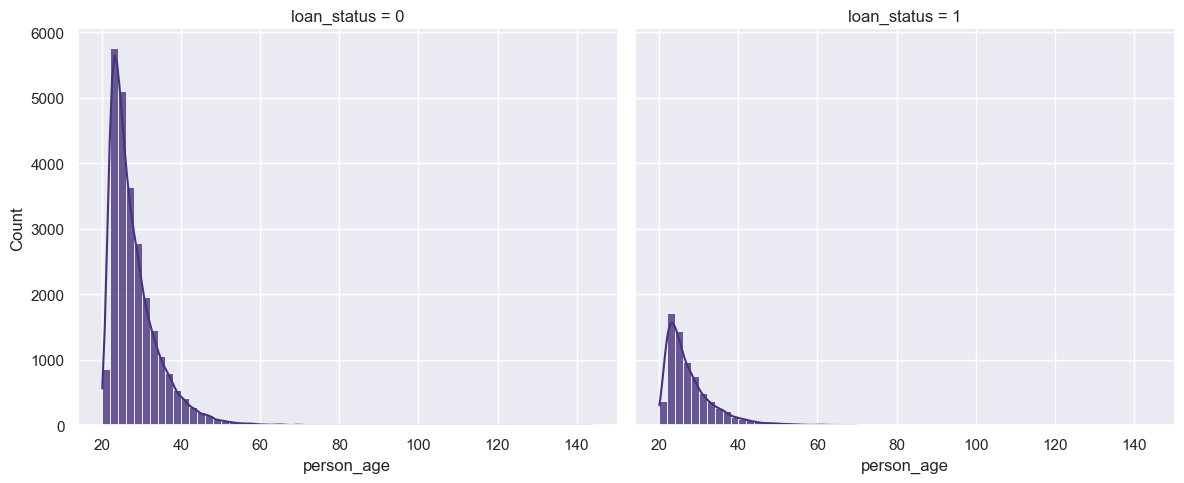

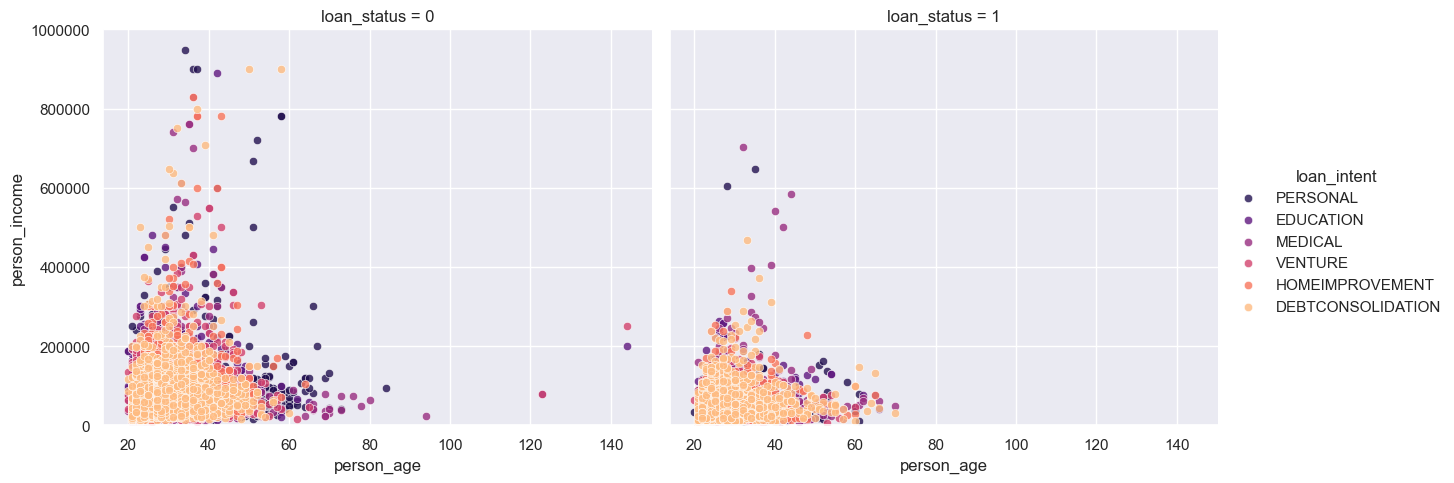

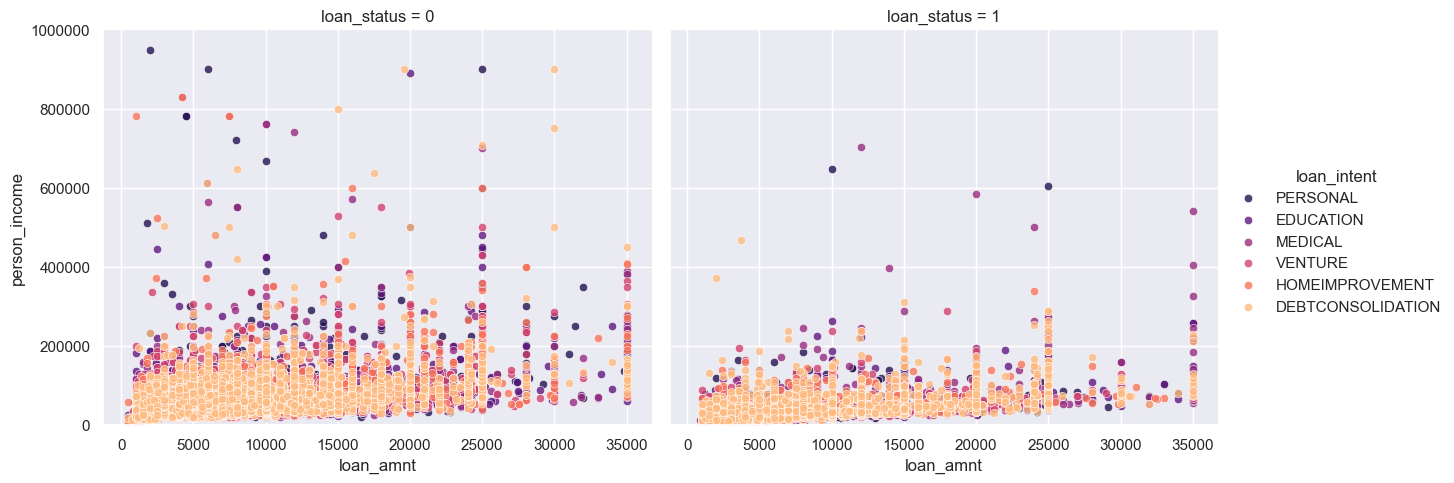

In [ ]:
plt.figure()
q= sns.FacetGrid(data= df, col= 'loan_status', height= 5, aspect= 1.2, palette= 'Dark2')
q.map(sns.histplot, 'person_age', binwidth= 2, kde= True, alpha= .8)
q= sns.FacetGrid(data= df, col= 'loan_status', height= 5, aspect= 1.2, hue= 'loan_intent', palette= 'magma')
q.map(sns.scatterplot, 'person_age', 'person_income', alpha= .8)
q.add_legend()
plt.ticklabel_format(style='plain', axis='y')
plt.ylim((0, 1000000))
q= sns.FacetGrid(data= df, col= 'loan_status', height= 5, aspect= 1.2, hue= 'loan_intent', palette= 'magma')
q.map(sns.scatterplot,'loan_amnt', 'person_income', alpha= .8)
q.add_legend()
plt.ticklabel_format(style='plain', axis='y')
plt.ylim((0, 1000000))
plt.show()
# are young people / low income people likely to default ?
# not really people of all ages do default, but there is a clear insight about the income
# those with higher income default less regardless of age.
# outliers appear, we'll deal with them later in preprocessing step (4 loans so far)
# it appears most of those that do default are below 40 yr old, interesting

In [ ]:
# we see many Loans related to Debt consolidated are being defaulted